In [63]:
import random

import numpy as np
import  pandas as pd
from sklearn.datasets import make_classification

In [2]:
X, y = make_classification(n_features=5, n_redundant=0, n_informative=5, n_clusters_per_class=1)

In [3]:
df = pd.DataFrame(X, columns = ['col1', 'col2', 'col3', 'col4', 'col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-0.385018,-0.644558,-1.675538,-0.492406,1.101220,1
1,2.250505,2.108200,0.051789,2.298393,-0.065358,0
2,-0.635856,-1.154645,-0.550987,3.514372,-2.380402,1
3,-0.180517,-0.122539,-0.974825,1.806137,0.972175,1
4,1.038943,-1.212091,-1.220343,1.165028,2.937014,0


In [4]:
# function for row sampling
def sample_rows(df, percent):
    return df.sample(int(percent * df.shape[0]), replace=True)

In [71]:
# Function for feature sampling
def sample_features(df, percent):
    cols = random.sample(df.columns.tolist()[:-1], int(percent * (df.shape[1] - 1)))
    new_df = df[cols]
    new_df['target'] = df['target']
    return new_df

In [8]:
# Function for combined sampling
def combined_sampling(df, row_percent, col_percent):
    new_df = sample_rows(df, row_percent)
    return sample_features(new_df, col_percent)

In [42]:
df1 = sample_rows(df, 0.2)

In [43]:
df2 = sample_rows(df, 0.2)

In [44]:
df3 = sample_rows(df, 0.2)

In [45]:
df1.shape

(20, 6)

In [46]:
df2.shape

(20, 6)

In [47]:
df3.shape

(20, 6)

In [48]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [49]:
clf1.fit(df1.iloc[:, 0:5], df1.iloc[:, -1])
clf2.fit(df2.iloc[:, 0:5], df2.iloc[:, -1])
clf3.fit(df3.iloc[:, 0:5], df3.iloc[:, -1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [50]:
from sklearn.tree import plot_tree

[Text(0.5, 0.8333333333333334, 'x[1] <= 0.058\ngini = 0.495\nsamples = 20\nvalue = [11, 9]'),
 Text(0.25, 0.5, 'x[0] <= 0.954\ngini = 0.198\nsamples = 9\nvalue = [1, 8]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.375, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.75, 0.5, 'x[0] <= -1.541\ngini = 0.165\nsamples = 11\nvalue = [10, 1]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.875, 0.16666666666666666, 'gini = 0.0\nsamples = 10\nvalue = [10, 0]')]

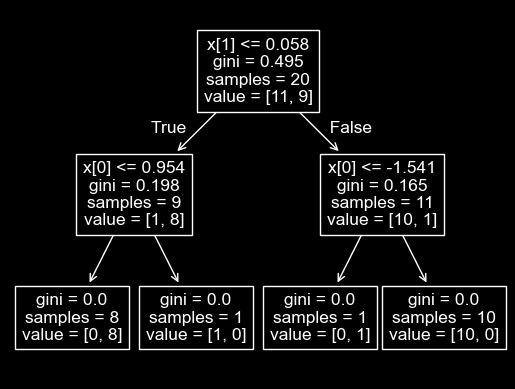

In [51]:
plot_tree(clf1)

[Text(0.6, 0.8333333333333334, 'x[2] <= 0.979\ngini = 0.48\nsamples = 20\nvalue = [8, 12]'),
 Text(0.4, 0.5, 'x[0] <= 1.659\ngini = 0.142\nsamples = 13\nvalue = [1, 12]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 12\nvalue = [0, 12]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.7, 0.6666666666666667, '  False')]

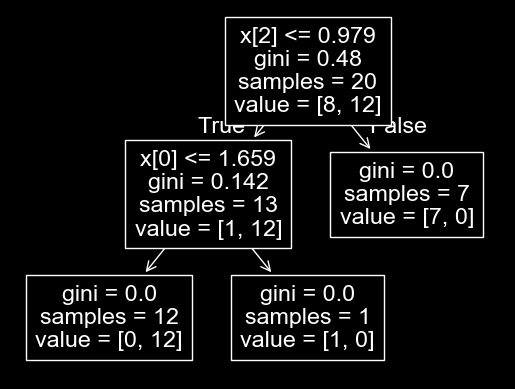

In [52]:
plot_tree(clf2)

[Text(0.5555555555555556, 0.875, 'x[1] <= 0.333\ngini = 0.375\nsamples = 20\nvalue = [5, 15]'),
 Text(0.3333333333333333, 0.625, 'x[1] <= -1.718\ngini = 0.124\nsamples = 15\nvalue = [1, 14]'),
 Text(0.4444444444444444, 0.75, 'True  '),
 Text(0.2222222222222222, 0.375, 'x[0] <= 0.56\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.1111111111111111, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.3333333333333333, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.4444444444444444, 0.375, 'gini = 0.0\nsamples = 13\nvalue = [0, 13]'),
 Text(0.7777777777777778, 0.625, 'x[3] <= 2.089\ngini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.6666666666666667, 0.75, '  False'),
 Text(0.6666666666666666, 0.375, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.8888888888888888, 0.375, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]')]

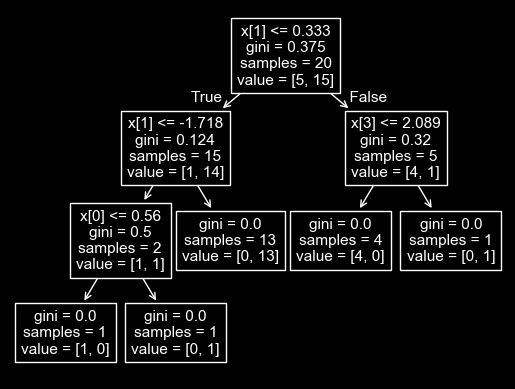

In [53]:
plot_tree(clf3)

In [55]:
clf1.predict(np.array([-0.385018, -0.644558, -1.675538, -0.492406, 1.101220]).reshape(1, 5))

C:\Users\rohit\AppData\Local\Programs\Python\Python311\python.exe\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [56]:
clf2.predict(np.array([-0.385018, -0.644558, -1.675538, -0.492406, 1.101220]).reshape(1, 5))

C:\Users\rohit\AppData\Local\Programs\Python\Python311\python.exe\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [57]:
clf3.predict(np.array([-0.385018, -0.644558, -1.675538, -0.492406, 1.101220]).reshape(1, 5))

C:\Users\rohit\AppData\Local\Programs\Python\Python311\python.exe\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [72]:
df1 = sample_features(df, 0.8)

In [82]:
print(df1.columns)

Index(['col5', 'col2', 'col3', 'col4', 'target'], dtype='str')


In [73]:
df2 = sample_features(df, 0.8)

In [81]:
print(df2.columns)

Index(['col1', 'col4', 'col3', 'col5', 'target'], dtype='str')


In [74]:
df3 = sample_features(df, 0.8)

In [83]:
df3

,col1,col5,col3,col2,target
0,-0.385018,1.101220,-1.675538,-0.644558,1
1,2.250505,-0.065358,0.051789,2.108200,0
2,-0.635856,-2.380402,-0.550987,-1.154645,1
3,-0.180517,0.972175,-0.974825,-0.122539,1
4,1.038943,2.937014,-1.220343,-1.212091,0
...,...,...,...,...,...
95,2.096184,0.275063,1.866260,1.666825,0
96,-1.682220,3.094179,-2.096099,-1.249669,1
97,-0.740139,0.184385,-1.591553,-0.751197,1
98,-0.244790,0.771387,-0.557267,-0.731697,1


In [80]:
print(df3.columns)

Index(['col1', 'col5', 'col3', 'col2', 'target'], dtype='str')


In [75]:
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [76]:
clf1.fit(df1.iloc[:, 0:4], df1.iloc[:, -1])
clf2.fit(df2.iloc[:, 0:4], df2.iloc[:, -1])
clf3.fit(df3.iloc[:, 0:4], df3.iloc[:, -1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

[Text(0.5, 0.9285714285714286, 'x[2] <= -0.123\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.25, 0.7857142857142857, 'x[1] <= 0.404\ngini = 0.286\nsamples = 52\nvalue = [9, 43]'),
 Text(0.375, 0.8571428571428572, 'True  '),
 Text(0.125, 0.6428571428571429, 'x[0] <= 0.866\ngini = 0.206\nsamples = 43\nvalue = [5, 38]'),
 Text(0.0625, 0.5, 'gini = 0.0\nsamples = 23\nvalue = [0, 23]'),
 Text(0.1875, 0.5, 'x[3] <= 0.283\ngini = 0.375\nsamples = 20\nvalue = [5, 15]'),
 Text(0.125, 0.35714285714285715, 'gini = 0.0\nsamples = 9\nvalue = [0, 9]'),
 Text(0.25, 0.35714285714285715, 'x[2] <= -0.979\ngini = 0.496\nsamples = 11\nvalue = [5, 6]'),
 Text(0.1875, 0.21428571428571427, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.3125, 0.21428571428571427, 'x[2] <= -0.458\ngini = 0.375\nsamples = 8\nvalue = [2, 6]'),
 Text(0.25, 0.07142857142857142, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.375, 0.07142857142857142, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.642

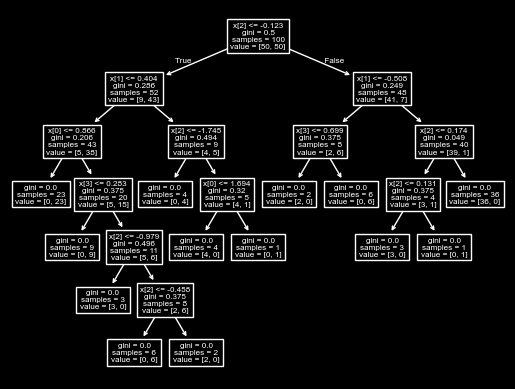

In [77]:
plot_tree(clf1)

[Text(0.4642857142857143, 0.9166666666666666, 'x[2] <= -0.123\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.21428571428571427, 0.75, 'x[0] <= 0.41\ngini = 0.286\nsamples = 52\nvalue = [9, 43]'),
 Text(0.3392857142857143, 0.8333333333333333, 'True  '),
 Text(0.14285714285714285, 0.5833333333333334, 'x[0] <= 0.117\ngini = 0.044\nsamples = 44\nvalue = [1, 43]'),
 Text(0.07142857142857142, 0.4166666666666667, 'gini = 0.0\nsamples = 41\nvalue = [0, 41]'),
 Text(0.21428571428571427, 0.4166666666666667, 'x[3] <= -0.052\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.14285714285714285, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.2857142857142857, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.2857142857142857, 0.5833333333333334, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]'),
 Text(0.7142857142857143, 0.75, 'x[3] <= 2.047\ngini = 0.249\nsamples = 48\nvalue = [41, 7]'),
 Text(0.5892857142857143, 0.8333333333333333, '  False'),
 Text(0.5714285714285714, 0.58

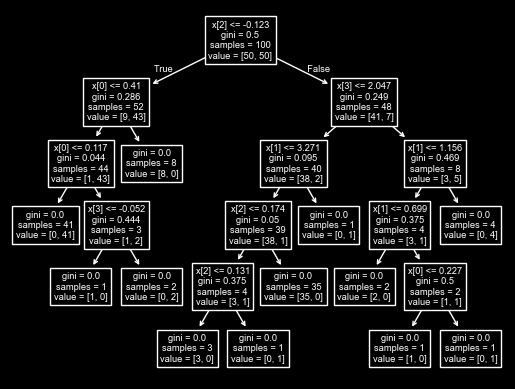

In [78]:
plot_tree(clf2)

[Text(0.4583333333333333, 0.9, 'x[2] <= -0.123\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.25, 0.7, 'x[0] <= 0.41\ngini = 0.286\nsamples = 52\nvalue = [9, 43]'),
 Text(0.35416666666666663, 0.8, 'True  '),
 Text(0.16666666666666666, 0.5, 'x[3] <= 1.945\ngini = 0.044\nsamples = 44\nvalue = [1, 43]'),
 Text(0.08333333333333333, 0.3, 'gini = 0.0\nsamples = 43\nvalue = [0, 43]'),
 Text(0.25, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.3333333333333333, 0.5, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]'),
 Text(0.6666666666666666, 0.7, 'x[3] <= -0.508\ngini = 0.249\nsamples = 48\nvalue = [41, 7]'),
 Text(0.5625, 0.8, '  False'),
 Text(0.5, 0.5, 'x[2] <= 0.263\ngini = 0.375\nsamples = 8\nvalue = [2, 6]'),
 Text(0.4166666666666667, 0.3, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.5833333333333334, 0.3, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.8333333333333334, 0.5, 'x[2] <= 0.174\ngini = 0.049\nsamples = 40\nvalue = [39, 1]'),
 Text(0.75, 0.3, 'x[2] <= 0

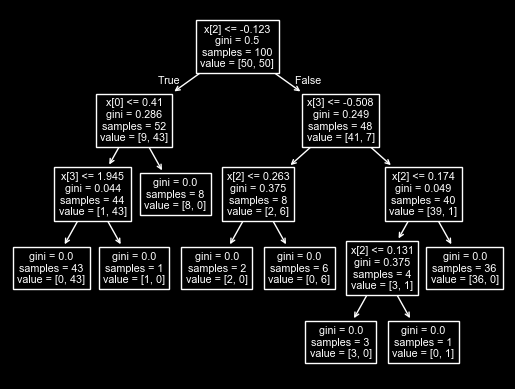

In [79]:
plot_tree(clf3)

In [84]:
clf1.predict(np.array([-0.180517, 0.972175, -0.974825, -0.122539]).reshape(1, 4))

C:\Users\rohit\AppData\Local\Programs\Python\Python311\python.exe\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [85]:
clf2.predict(np.array([-0.180517, 0.972175, -0.974825, -0.122539]).reshape(1, 4))

C:\Users\rohit\AppData\Local\Programs\Python\Python311\python.exe\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [86]:
clf3.predict(np.array([-0.180517, 0.972175, -0.974825, -0.122539]).reshape(1, 4))

C:\Users\rohit\AppData\Local\Programs\Python\Python311\python.exe\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [89]:
df1 = combined_sampling(df, 0.5, 0.5)

In [90]:
df2 = combined_sampling(df, 0.5, 0.5)

In [91]:
df3 = combined_sampling(df, 0.5, 0.5)

In [92]:
print(df1.columns)
print(df2.columns)
print(df3.columns)


Index(['col2', 'col1', 'target'], dtype='str')
Index(['col5', 'col3', 'target'], dtype='str')
Index(['col5', 'col2', 'target'], dtype='str')


In [93]:
df3

,col5,col2,target
56,3.500543,-1.940096,0
37,-0.462869,-1.495864,1
30,2.149034,-2.141111,1
57,2.533040,-1.471187,1
80,1.735781,-1.242114,1
47,-0.280808,-1.432720,1
22,0.715437,-1.262186,1
51,0.689754,-2.308660,1
97,0.184385,-0.751197,1
96,3.094179,-1.249669,1


In [94]:
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [95]:
clf1.fit(df1.iloc[:, 0:2], df1.iloc[:, -1])
clf2.fit(df2.iloc[:, 0:2], df2.iloc[:, -1])
clf3.fit(df3.iloc[:, 0:2], df3.iloc[:, -1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

[Text(0.5, 0.9, 'x[0] <= -0.718\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.3, 0.7, 'x[1] <= 0.995\ngini = 0.172\nsamples = 21\nvalue = [2, 19]'),
 Text(0.4, 0.8, 'True  '),
 Text(0.2, 0.5, 'x[1] <= 0.214\ngini = 0.095\nsamples = 20\nvalue = [1, 19]'),
 Text(0.1, 0.3, 'gini = 0.0\nsamples = 15\nvalue = [0, 15]'),
 Text(0.3, 0.3, 'x[0] <= -1.322\ngini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.2, 0.1, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.4, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.4, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.7, 0.7, 'x[1] <= -2.098\ngini = 0.328\nsamples = 29\nvalue = [23, 6]'),
 Text(0.6, 0.8, '  False'),
 Text(0.6, 0.5, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.8, 0.5, 'x[0] <= 0.64\ngini = 0.147\nsamples = 25\nvalue = [23, 2]'),
 Text(0.7, 0.3, 'x[1] <= 0.492\ngini = 0.444\nsamples = 6\nvalue = [4, 2]'),
 Text(0.6, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.8, 0.1, 'gini = 0.0\nsampl

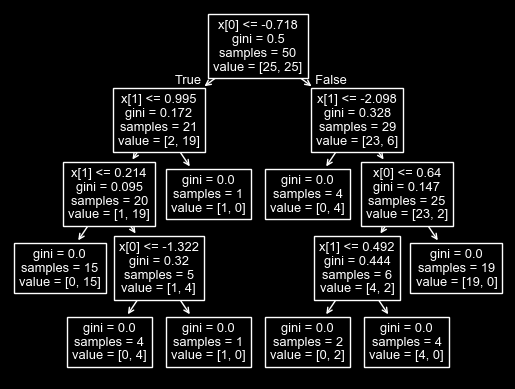

In [96]:
plot_tree(clf1)

[Text(0.43333333333333335, 0.9285714285714286, 'x[1] <= -0.739\ngini = 0.493\nsamples = 50\nvalue = [28.0, 22.0]'),
 Text(0.2, 0.7857142857142857, 'x[1] <= -1.406\ngini = 0.198\nsamples = 18\nvalue = [2, 16]'),
 Text(0.31666666666666665, 0.8571428571428572, 'True  '),
 Text(0.13333333333333333, 0.6428571428571429, 'gini = 0.0\nsamples = 10\nvalue = [0, 10]'),
 Text(0.26666666666666666, 0.6428571428571429, 'x[0] <= 2.567\ngini = 0.375\nsamples = 8\nvalue = [2, 6]'),
 Text(0.2, 0.5, 'x[0] <= -0.021\ngini = 0.245\nsamples = 7\nvalue = [1, 6]'),
 Text(0.13333333333333333, 0.35714285714285715, 'x[0] <= -0.96\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.06666666666666667, 0.21428571428571427, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.2, 0.21428571428571427, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.26666666666666666, 0.35714285714285715, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.3333333333333333, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.66

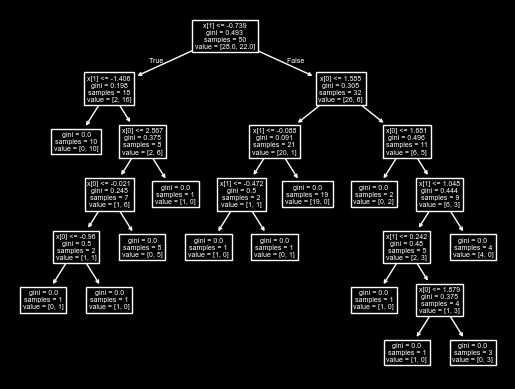

In [97]:
plot_tree(clf2)

[Text(0.6538461538461539, 0.9166666666666666, 'x[1] <= 1.016\ngini = 0.493\nsamples = 50\nvalue = [22.0, 28.0]'),
 Text(0.5769230769230769, 0.75, 'x[0] <= 2.735\ngini = 0.346\nsamples = 36\nvalue = [8, 28]'),
 Text(0.6153846153846154, 0.8333333333333333, 'True  '),
 Text(0.3076923076923077, 0.5833333333333334, 'x[1] <= 0.672\ngini = 0.185\nsamples = 29\nvalue = [3, 26]'),
 Text(0.15384615384615385, 0.4166666666666667, 'x[0] <= 1.615\ngini = 0.08\nsamples = 24\nvalue = [1, 23]'),
 Text(0.07692307692307693, 0.25, 'gini = 0.0\nsamples = 18\nvalue = [0, 18]'),
 Text(0.23076923076923078, 0.25, 'x[0] <= 1.71\ngini = 0.278\nsamples = 6\nvalue = [1, 5]'),
 Text(0.15384615384615385, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.3076923076923077, 0.08333333333333333, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.46153846153846156, 0.4166666666666667, 'x[0] <= 0.73\ngini = 0.48\nsamples = 5\nvalue = [2, 3]'),
 Text(0.38461538461538464, 0.25, 'gini = 0.0\nsamples =

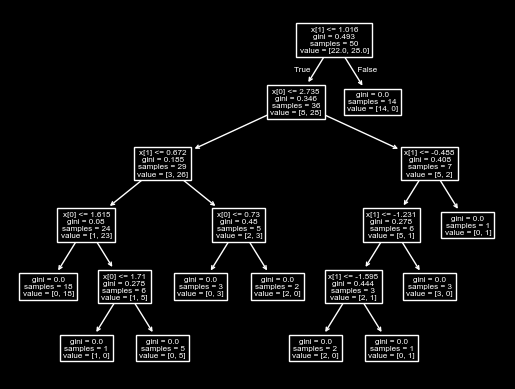

In [98]:
plot_tree(clf3)

In [102]:
clf1.predict(np.array([0.428551,-0.766876]).reshape(1, 2))

C:\Users\rohit\AppData\Local\Programs\Python\Python311\python.exe\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [103]:
clf2.predict(np.array([0.428551,-0.766876]).reshape(1, 2))

C:\Users\rohit\AppData\Local\Programs\Python\Python311\python.exe\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [104]:
clf3.predict(np.array([0.428551,-0.766876]).reshape(1, 2))

C:\Users\rohit\AppData\Local\Programs\Python\Python311\python.exe\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])